# Finance Banking Data

In [22]:
## Libraries Import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
## Dataset Load

df = pd.read_csv("C:/Users/palla/Desktop/finance_banking_data.csv")
df.head()

,Customer_ID,Age,Gender,Account_Type,Account_Balance,Loan_Amount,Credit_Score,Transaction_Count,Last_Transaction_Days
0,19412.0,30.0,M,NaN,1000.0,50000.0,600.0,5.0,1.0
1,10537.0,40.0,Male,Savings,25000.0,50000.0,600.0,20.0,1.0
2,15699.0,18.0,M,NaN,25000.0,50000.0,NaN,0.0,-10.0
3,14307.0,18.0,Female,NaN,1000.0,NaN,900.0,20.0,5.0
4,10919.0,NaN,Female,Loan,1000.0,200000.0,NaN,0.0,-10.0


In [24]:
## Rows and Column Check

df.shape

(5070, 9)

In [25]:
## Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5070 entries, 0 to 5069
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            5069 non-null   float64
 1   Age                    4443 non-null   float64
 2   Gender                 4129 non-null   object 
 3   Account_Type           2994 non-null   object 
 4   Account_Balance        4218 non-null   float64
 5   Loan_Amount            4055 non-null   float64
 6   Credit_Score           4210 non-null   float64
 7   Transaction_Count      4066 non-null   float64
 8   Last_Transaction_Days  4214 non-null   float64
dtypes: float64(7), object(2)
memory usage: 356.6+ KB


### Data Cleaning

In [26]:
## Missing Values Check

df.isnull().sum()

Customer_ID                 1
Age                       627
Gender                    941
Account_Type             2076
Account_Balance           852
Loan_Amount              1015
Credit_Score              860
Transaction_Count        1004
Last_Transaction_Days     856
dtype: int64

In [27]:
## Missing Values Handle

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Account_Balance'] = df['Account_Balance'].fillna(df['Account_Balance'].mean())
df['Loan_Amount'] = df['Loan_Amount'].fillna(0)
df['Gender'] = df['Gender'].fillna("Unknown")

In [28]:
## Missing Values Check

df.isnull().sum()

Customer_ID                 1
Age                         0
Gender                      0
Account_Type             2076
Account_Balance             0
Loan_Amount                 0
Credit_Score              860
Transaction_Count        1004
Last_Transaction_Days     856
dtype: int64

In [29]:
## Customer_ID
df = df.dropna(subset=['Customer_ID'])

In [30]:
## Account_Type
df['Account_Type'] = df['Account_Type'].fillna("Unknown")

In [31]:
## Credit_Score
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())

In [32]:
## Transaction_Count
df['Transaction_Count'] = df['Transaction_Count'].fillna(
    df['Transaction_Count'].median()
)

In [33]:
df.isnull().sum()

Customer_ID                0
Age                        0
Gender                     0
Account_Type               0
Account_Balance            0
Loan_Amount                0
Credit_Score               0
Transaction_Count          0
Last_Transaction_Days    856
dtype: int64

In [34]:
df['Last_Transaction_Days'] = df['Last_Transaction_Days'].fillna(0)



In [35]:
df.isnull().sum()

Customer_ID              0
Age                      0
Gender                   0
Account_Type             0
Account_Balance          0
Loan_Amount              0
Credit_Score             0
Transaction_Count        0
Last_Transaction_Days    0
dtype: int64

In [36]:
df[['Transaction_Count', 'Last_Transaction_Days']].describe()


,Transaction_Count,Last_Transaction_Days
count,5069.000000,5069.000000
mean,4.173604,35.458670
std,8.067582,67.088317
min,-3.000000,-10.000000
25%,0.000000,0.000000
50%,0.000000,5.000000
75%,5.000000,30.000000
max,20.000000,180.000000


In [37]:
## Duplicate Rows 
df.duplicated().sum()


70

In [38]:
## Negative Values Remove

df = df[df['Age'] > 0]
df = df[df['Account_Balance'] >= 0]
df = df[df['Loan_Amount'] >= 0]
df = df[df['Transaction_Count'] >= 0]


In [39]:
## Gender Check 
df['Gender'] = df['Gender'].replace({'M':'Male', 'F':'Female'})
df['Gender'].value_counts()


Gender
Male       959
Female     949
Unknown    434
Name: count, dtype: int64

In [40]:

np.mean(df['Account_Balance'])


32191.95639524643

In [41]:
np.median(df['Loan_Amount'])


0.0

### Data Visualization 

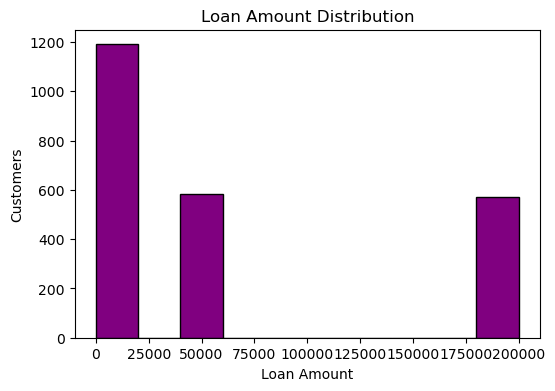

In [43]:
plt.figure(figsize=(6,4))                                          #X-axis (horizontal):
plt.hist(df['Loan_Amount'], color='purple', edgecolor='black')    #Loan ki amount (customers ne kitna loan liya)
plt.title("Loan Amount Distribution")                              #Y-axis (vertical):
plt.xlabel("Loan Amount")                                          #Kitne customers ne us range ka loan liya
plt.ylabel("Customers")
plt.show()

         

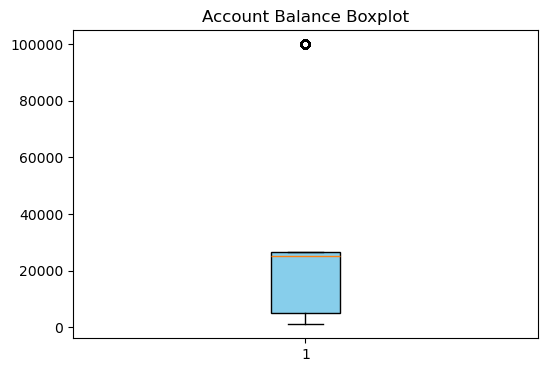

In [44]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Account_Balance'], patch_artist=True,
            boxprops=dict(facecolor='skyblue'))
plt.title("Account Balance Boxplot")
plt.show()


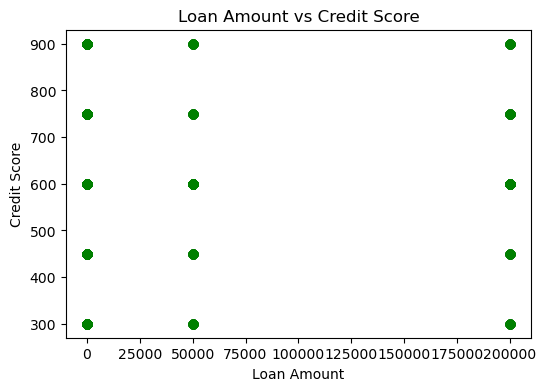

In [45]:
plt.figure(figsize=(6,4))
plt.scatter(df['Loan_Amount'], df['Credit_Score'], color='green')
plt.title("Loan Amount vs Credit Score")
plt.xlabel("Loan Amount")
plt.ylabel("Credit Score")
plt.show()


#Agar dots upar ki taraf trend kar rahe hain:
#Matlab jinka credit score achha hai, unko zyada loan milta hai

#Agar dots scattered hain:
#Matlab credit score akela factor nahi hai



<Axes: xlabel='Gender', ylabel='count'>

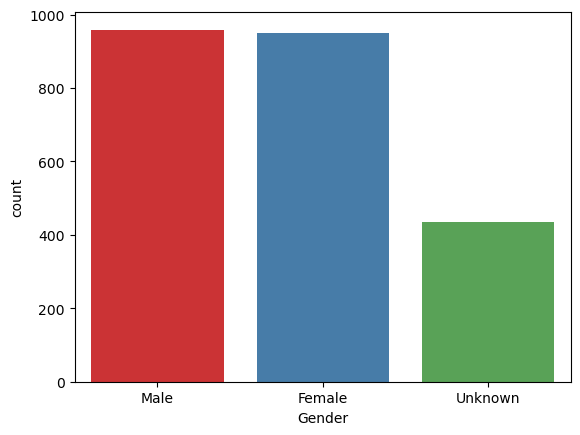

In [46]:
sns.countplot(
    x='Gender',
    hue='Gender',
    data=df,
    palette='Set1',
    legend=False
)

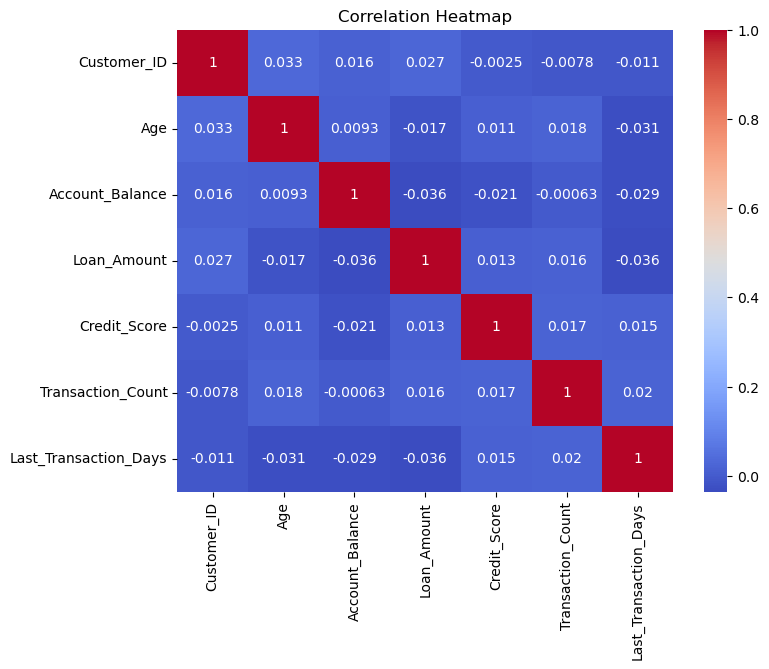

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#Value +1 that means strong positive relation.
#Value -1 that means strong negative relation.
#Value 0 that means almost no relation.

# Heatmap - check the visually understand the relationship pattern,density between the data.

### Conclusion